# NB103 - Visualize predictions (best.pt vs last.pt)

Qualitative viewer for the `combined_aux_gca_full` model (NB101). The scalars say
lanes ARE learning (curve-F1 0.05->0.30, the best in the project) but pixel-IoU
plateaus ~0.11 and lane_precision (0.24) << lane_recall (0.40) - i.e. the model
**over-predicts** lanes and the geometry isn't pixel-sharp. Numbers can't show
*which* lanes are wrong, so this notebook draws the real predictions.

**What it shows, per sample image (3 panels):**
1. **Ground truth** - GT polyline lanes (green) + GT vehicle boxes (red)
2. **best.pt prediction** - decoded predicted lanes (yellow) + pred boxes (cyan)
3. **last.pt prediction** - same, for the final-epoch weights

Lanes are decoded with the SAME per-lane decoder used by the curve-F1 metric
(`P7_validator/tools/lane_curve_f1._decode_row`), so what you see == what the
metric scored. Detection boxes come straight from the model's eval output.

> The aux drivable + lane-seg heads are **training-only** and are dropped at
> eval, so these panels are the true deployable model (detection + CLR polyline).

**Flow:** Cell 1 mount+deps -> Cell 2 fetch weights from Drive + extract a few
val images to /content/ -> Cell 3 define the load+infer+draw helpers -> Cell 4
render best vs last on N samples -> Cell 5 a "failure gallery" (worst cases).


### Cell 1: Mount Drive + install deps + locate repo

In [1]:
import os, sys, subprocess
from pathlib import Path

os.environ['PYTHONIOENCODING'] = 'utf-8'
if not Path('/content/drive').exists():
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)

REPO_ROOT = '/content/drive/MyDrive/EcoCAR/yolop_vehicle_lane'
if not os.path.isdir(REPO_ROOT):
    raise FileNotFoundError(f'Missing {REPO_ROOT} -- verify Drive sync.')
os.chdir(REPO_ROOT)
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

for _pkg in ('addict', 'yapf'):
    try: __import__(_pkg)
    except ImportError: subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', _pkg])
for _m in ('mmcv',):
    try: __import__(_m)
    except ImportError: subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', _m])
try:
    import cv2  # noqa: F401
except ImportError:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'opencv-python-headless'])

MIG       = Path(REPO_ROOT) / 'stage2/rmt_ppad_migration'
RMT       = MIG / 'vendor/RMT-PPAD'
CKPT_DIR  = Path('/content/drive/MyDrive/EcoCAR/training_runs/checkpoints/combined_aux_gca_full')
DATASETS  = Path('/content/drive/MyDrive/EcoCAR/datasets')
FULL      = Path('/content/bdd_dataset')
print('[ok] repo =', MIG)
print('[ok] checkpoint dir exists:', CKPT_DIR.exists())
for w in ('best.pt', 'last.pt'):
    print(f'   {w}:', (CKPT_DIR / w).exists())


Mounted at /content/drive
[ok] repo = /content/drive/MyDrive/EcoCAR/yolop_vehicle_lane/stage2/rmt_ppad_migration
[ok] checkpoint dir exists: True
   best.pt: True
   last.pt: True


### Cell 2: Get weights + a handful of val images onto /content/

The .pt files are read straight from Drive. Val images: if the full subset
isn't already on /content/ (a fresh session), extract just the val images +
lane_targets + labels from NB102's complete-dataset tar (fast, one file). We
only need a few dozen images to look at, but the tar is the simplest source.


In [2]:
import tarfile

# Weights (read from Drive directly).
BEST = CKPT_DIR / 'best.pt'
LAST = CKPT_DIR / 'last.pt'
have_best, have_last = BEST.exists(), LAST.exists()
if not (have_best or have_last):
    raise FileNotFoundError(f'No best.pt/last.pt under {CKPT_DIR} - check the run synced to Drive.')
print('[weights] best:', have_best, ' last:', have_last)

# Val images + GT (for the GT panel). Reuse /content/bdd_dataset if present.
val_img = FULL / 'images/val2017'
if val_img.exists() and any(val_img.glob('*.jpg')):
    print(f'[data] using existing {val_img}')
else:
    tar = DATASETS / 'bdd_complete_labels_70k.tar.gz'
    curve = DATASETS / 'bdd100k_clrkd_curve.tar'
    # complete-labels tar gives labels+lane_targets+drivable; the curve tar has images.
    if curve.exists():
        print(f'[data] extracting val images from {curve.name} (this has the jpgs)...', flush=True)
        with tarfile.open(curve) as tf:
            members = [m for m in tf.getmembers()
                       if ('/val' in m.name or '/val2017' in m.name) and m.name.endswith('.jpg')]
            # take first 60 val jpgs only - we just need samples
            members = members[:60]
            for m in members:
                tf.extract(m, '/content/_curve_scratch')
        # normalize into FULL/images/val2017
        scratch = Path('/content/_curve_scratch')
        dst = val_img; dst.mkdir(parents=True, exist_ok=True)
        for jp in scratch.rglob('*.jpg'):
            (dst / jp.name).write_bytes(jp.read_bytes())
        print(f'[data] staged {sum(1 for _ in dst.glob("*.jpg"))} val images -> {dst}')
    else:
        raise FileNotFoundError(
            f'No val images on /content/ and {curve} not found. Run NB101/NB102 '
            'first (they extract /content/bdd_dataset), or place the curve tar on Drive.')

# GT labels/lane_targets (optional - only for the GT panel). Pull from complete tar.
lt = FULL / 'lane_targets/val2017'
if not (lt.exists() and any(lt.glob('*.pt'))):
    tar = DATASETS / 'bdd_complete_labels_70k.tar.gz'
    if tar.exists():
        print(f'[data] extracting GT labels from {tar.name}...', flush=True)
        with tarfile.open(tar) as tf:
            tf.extractall(FULL)
        print('[data] GT lane_targets/labels extracted')
    else:
        print('[warn] no complete-labels tar -> GT panel will show image only')
print('[ok] data staged')


[weights] best: True  last: True
[data] extracting val images from bdd100k_clrkd_curve.tar (this has the jpgs)...
[data] staged 60 val images -> /content/bdd_dataset/images/val2017
[data] extracting GT labels from bdd_complete_labels_70k.tar.gz...


/tmp/ipykernel_795/3518289167.py:27: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tf.extract(m, '/content/_curve_scratch')
/tmp/ipykernel_795/3518289167.py:46: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tf.extractall(FULL)


[data] GT lane_targets/labels extracted
[ok] data staged


### Cell 3: Load helpers - model, raw inference, per-lane decode, draw

Builds the model with the SAME path the validator uses (vendor-first import,
fuse disabled). `infer(model, img)` returns decoded lanes + detection boxes in
the 640 frame. `draw(...)` overlays them. Lanes are decoded with the curve-F1
metric's own `_decode_row`, so panels == what the metric scored.


In [3]:
import importlib.util, numpy as np, cv2, torch

def _ensure_vendor_first(rmt_root):
    p = str(Path(rmt_root).resolve())
    sys.path[:] = [x for x in sys.path if 'ultralytics' not in x.lower()]
    if p in sys.path: sys.path.remove(p)
    sys.path.insert(0, p)
    for k in list(sys.modules):
        if k == 'ultralytics' or k.startswith('ultralytics.'):
            del sys.modules[k]

# curve-F1 decoder (the proven per-lane decode used by the metric)
_spec = importlib.util.spec_from_file_location('lcf1', MIG/'P7_validator/tools/lane_curve_f1.py')
lcf1 = importlib.util.module_from_spec(_spec); _spec.loader.exec_module(lcf1)

S = 640
os.environ['USE_AUX_SEG'] = '1'; os.environ.setdefault('AUX_SEG_CLASSES', '2')  # aux row weights need the submodule to load
os.environ.setdefault('LANE_MATCH', 'hungarian'); os.environ.setdefault('LANE_DIFF_CLAMP', '100')
_ensure_vendor_first(RMT)
from ultralytics import MTDETR

def load_model(weights):
    m = MTDETR(str(weights))
    inner = m.model
    inner.fuse = lambda *a, **k: inner            # fuse() is an inference-speed no-op that trips MTDETR; skip it
    inner.is_fused = lambda *a, **k: True
    inner.eval()
    return inner

def _preprocess(img_bgr):
    im = cv2.resize(img_bgr, (S, S))
    t = torch.from_numpy(cv2.cvtColor(im, cv2.COLOR_BGR2RGB)).permute(2,0,1).float()/255.0
    return t.unsqueeze(0)

@torch.no_grad()
def infer(model, img_bgr, conf=0.3, max_lanes=8, lane_topk=8):
    dev = next(model.parameters()).device
    x = _preprocess(img_bgr).to(dev)
    preds = model(x)
    # ---- detection boxes: preds[0] = (1, N, 4+nc) xywh (in 0..1 * imgsz handled below) ----
    boxes = []
    try:
        p0 = preds[0] if isinstance(preds, (list, tuple)) else preds
        bb, sc = p0[..., :4], p0[..., 4:]
        bb = bb[0]; sc = sc[0]
        conf_v, cls_v = sc.max(-1)
        keep = conf_v > conf
        bb = bb[keep] * S; conf_v = conf_v[keep]; cls_v = cls_v[keep]
        # xywh -> xyxy
        for (cx,cy,w,h), cf, cl in zip(bb.tolist(), conf_v.tolist(), cls_v.tolist()):
            boxes.append((int(cx-w/2), int(cy-h/2), int(cx+w/2), int(cy+h/2), cf, int(cl)))
    except Exception as e:
        print('[warn] box decode failed:', e)
    # ---- lanes: preds[1][5] = dict with eval-mode final_preds (1, num_priors, 78) ----
    lanes = []
    try:
        seg = preds[1][5]
        lo = seg.get('lane_output') if isinstance(seg, dict) else seg
        if isinstance(lo, dict): fp = lo['predictions_lists'][-1]
        elif isinstance(lo, (list, tuple)): fp = lo[-1]
        else: fp = lo
        rows = fp[0].detach().cpu().numpy()          # (num_priors, 78)
        order = np.argsort(-lcf1._softmax_pos(rows))[:lane_topk]
        for r in rows[order]:
            poly = lcf1._decode_row(r, S, 72, is_pred=True)   # (M,2) int in 640 frame, or None
            if poly is not None:
                lanes.append(poly)
    except Exception as e:
        print('[warn] lane decode failed:', e)
    return lanes, boxes

def draw(img_bgr, lanes, boxes, lane_color=(0,255,255), box_color=(255,255,0)):
    ov = cv2.cvtColor(cv2.resize(img_bgr, (S,S)), cv2.COLOR_BGR2RGB).copy()
    for (x1,y1,x2,y2,*rest) in boxes:
        cv2.rectangle(ov, (x1,y1),(x2,y2), box_color, 2)
    for poly in lanes:
        cv2.polylines(ov, [poly.reshape(-1,1,2)], False, lane_color, 3)
        cv2.circle(ov, tuple(poly[0]), 5, (255,0,0), -1)
    return ov

# GT decode (green) for the reference panel
NS=71; YS=np.arange(S,-1,-S/NS)[:72]
def gt_lanes(stem):
    tp = FULL/'lane_targets/val2017'/f'{stem}.pt'
    out=[]
    if tp.exists():
        tt=torch.load(tp, weights_only=True); t=(tt.numpy() if hasattr(tt,'numpy') else np.asarray(tt)).astype(np.float32)
        for row in t:
            if float(row[1])<0.5: continue
            st=max(0,min(int(round(float(row[2])*NS)),72)); L=max(0,min(int(round(float(row[5]))),72-st))
            if L<2: continue
            xs=np.asarray(row[6+st:6+st+L]); ys=YS[st:st+L]
            pts=[(int(round(x)),int(round(y))) for x,y in zip(xs,ys) if np.isfinite(x) and 0<=x<S]
            if len(pts)>=2: out.append(np.array(pts,np.int32))
    return out
def gt_boxes(stem):
    lp=FULL/'labels/val2017'/f'{stem}.txt'; out=[]
    if lp.exists():
        for ln in lp.read_text().splitlines():
            f=ln.split()
            if len(f)<5: continue
            cx,cy,w,h=(float(v) for v in f[1:5])
            out.append((int((cx-w/2)*S),int((cy-h/2)*S),int((cx+w/2)*S),int((cy+h/2)*S)))
    return out

print('[ok] helpers ready')


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
[ok] helpers ready


### Cell 4: Render GT vs best.pt vs last.pt on N sample images

Three columns per row. Yellow = predicted lanes, cyan = predicted boxes; green =
GT lanes, red = GT boxes. Look for: lanes hugging real markings, missed lanes
(low recall), spurious extra lanes (low precision), and best-vs-last drift.


In [5]:
import importlib as _il
for _shim in ('ultralytics.models.utils.lane_losses',   # registers p5_lane_losses
              'ultralytics.nn.modules.lane_head',        # registers p4_lane_seg_head
              'ultralytics.nn.modules.aux_seg_head'):    # registers aux_segmentors
    _il.import_module(_shim)
# then asserts all three names are now in sys.modules

showing: ['b1dd58c1-8b546ba7', 'b1d10d08-743fd86c', 'b1d9e136-6c94ea3f', 'b1df722f-5bcc3db7', 'b1d10d08-da110fcb', 'b1c81faa-c80764c5']


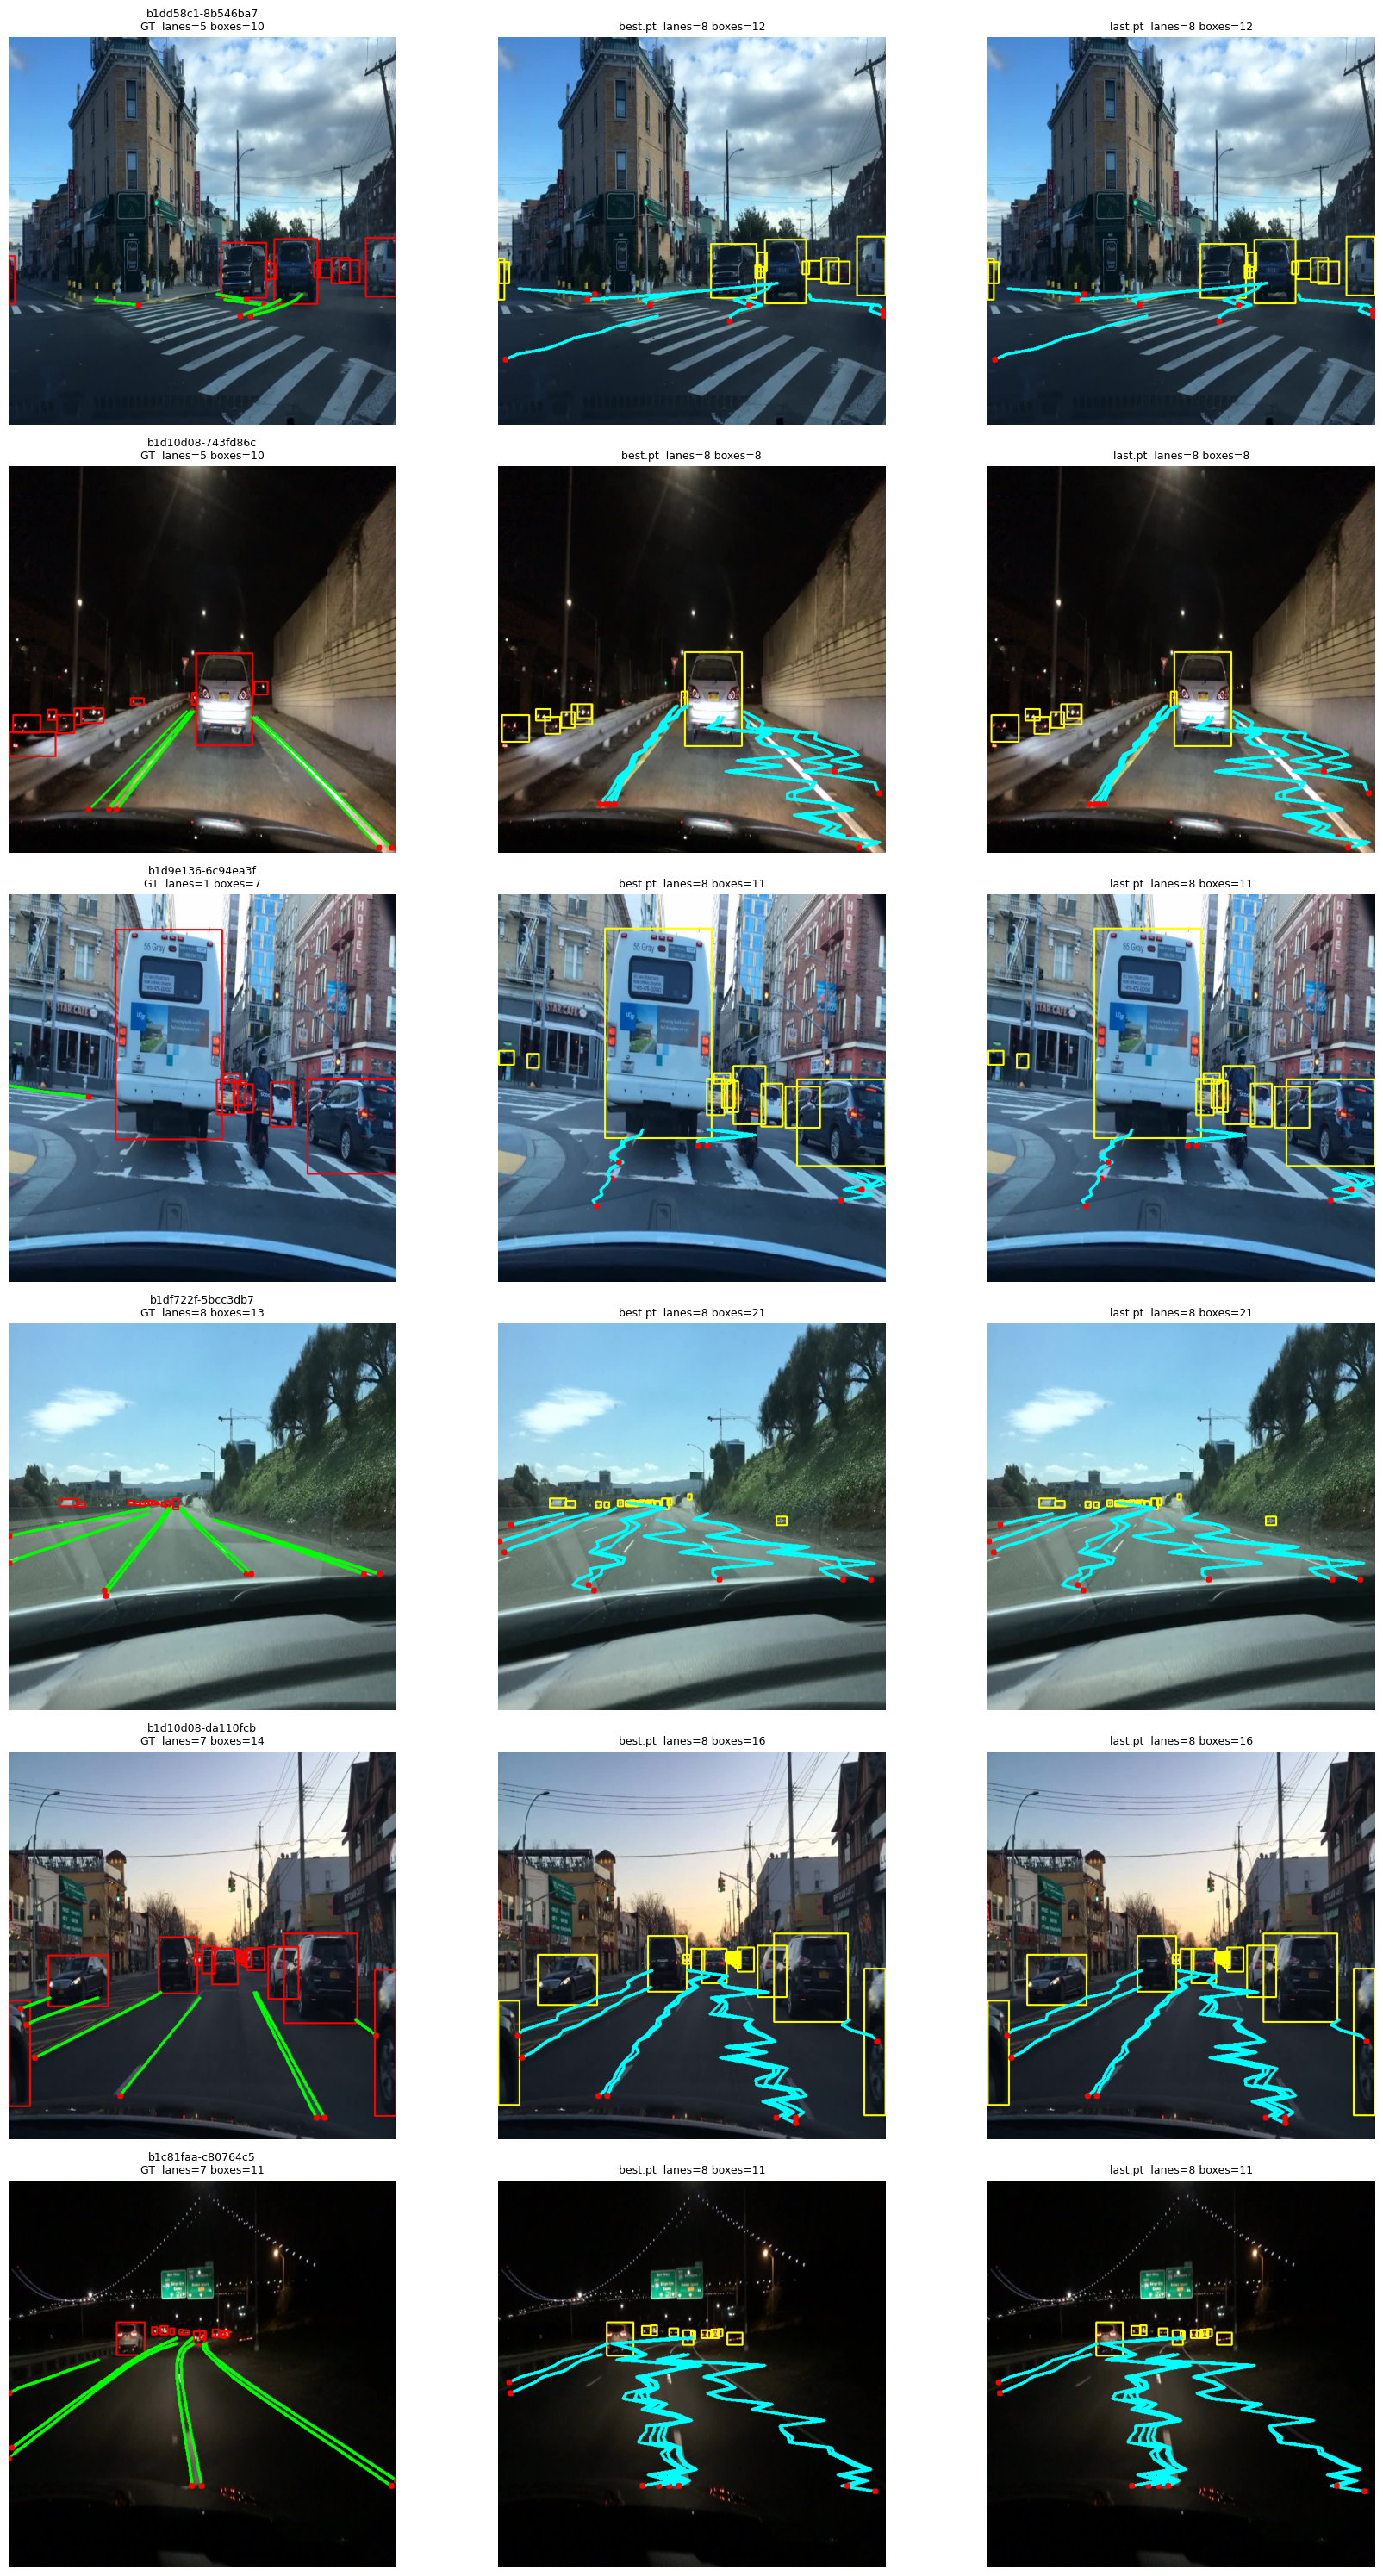

[saved] /content/nb103_pred_grid.png
READ: yellow pred-lanes should hug road markings. Missing yellow where green is = low recall. Yellow with no road marking = false positive (low precision).


In [6]:
import matplotlib.pyplot as plt, random

N_SHOW = 6
val_dir = FULL/'images/val2017'
stems = sorted(p.stem for p in val_dir.glob('*.jpg'))
random.seed(0); pick = random.sample(stems, min(N_SHOW, len(stems)))
print('showing:', pick)

m_best = load_model(BEST) if have_best else None
m_last = load_model(LAST) if have_last else None

ncol = 1 + (1 if m_best else 0) + (1 if m_last else 0)
fig, axes = plt.subplots(len(pick), ncol, figsize=(6*ncol, 5*len(pick)))
if len(pick)==1: axes=[axes]
for r, st in enumerate(pick):
    img = cv2.imread(str(val_dir/f'{st}.jpg'))
    row = axes[r] if ncol>1 else [axes[r]]
    c=0
    g = draw(img, gt_lanes(st), [(*b,1,0) for b in gt_boxes(st)], lane_color=(0,255,0), box_color=(255,0,0))
    row[c].imshow(g); row[c].set_title(f'{st}\nGT  lanes={len(gt_lanes(st))} boxes={len(gt_boxes(st))}', fontsize=9); row[c].axis('off'); c+=1
    if m_best:
        L,B = infer(m_best, img); row[c].imshow(draw(img,L,B)); row[c].set_title(f'best.pt  lanes={len(L)} boxes={len(B)}', fontsize=9); row[c].axis('off'); c+=1
    if m_last:
        L,B = infer(m_last, img); row[c].imshow(draw(img,L,B)); row[c].set_title(f'last.pt  lanes={len(L)} boxes={len(B)}', fontsize=9); row[c].axis('off'); c+=1
plt.tight_layout(); out='/content/nb103_pred_grid.png'; plt.savefig(out, dpi=80); plt.show()
print('[saved]', out)
print('READ: yellow pred-lanes should hug road markings. Missing yellow where '
      'green is = low recall. Yellow with no road marking = false positive (low precision).')


### Cell 5: Failure gallery - lowest per-image curve-F1 (best.pt)

Scores each shown image with the curve-F1 metric (pred vs GT) and surfaces the
WORST ones, so the model's drawbacks are explicit rather than cherry-picked.


worst-F1 images: [(0.0, 'b1ca8418-84a133a0'), (0.0, 'b1ceb32e-a106591d'), (0.0, 'b1d0a191-5490450b'), (0.0, 'b1d0a191-65deaeef')]


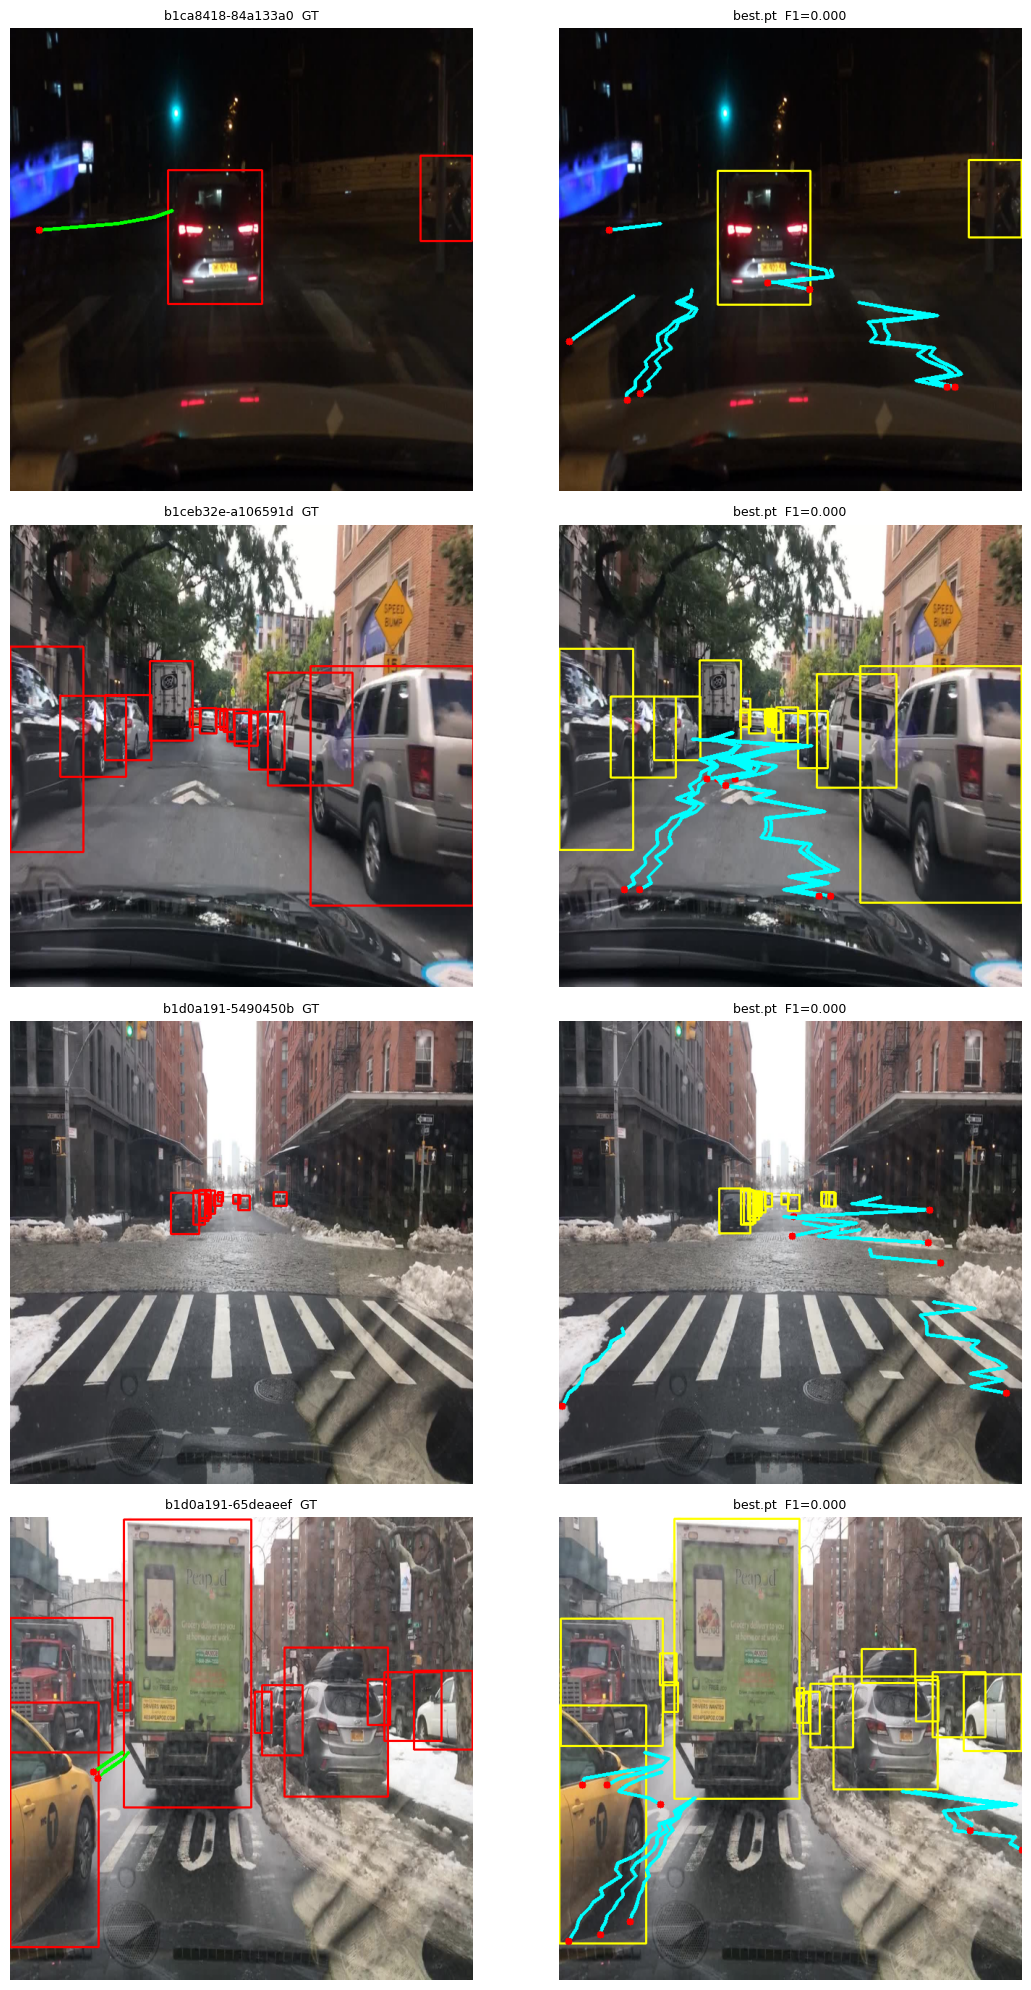

[saved] /content/nb103_failure_gallery.png
These are the model's weakest cases - look for the systematic failure (curves, merges, night, occlusion) to guide the next fix.


In [7]:
import matplotlib.pyplot as plt

if not have_best:
    print('[skip] no best.pt');
else:
    val_dir = FULL/'images/val2017'
    stems = sorted(p.stem for p in val_dir.glob('*.jpg'))[:40]   # score up to 40
    m = m_best if 'm_best' in globals() and m_best is not None else load_model(BEST)
    scored=[]
    for st in stems:
        tp = FULL/'lane_targets/val2017'/f'{st}.pt'
        if not tp.exists(): continue
        img = cv2.imread(str(val_dir/f'{st}.jpg'))
        # predicted rows for the metric
        dev=next(m.parameters()).device
        with torch.no_grad():
            preds=m(_preprocess(img).to(dev))
        seg=preds[1][5]; lo=seg.get('lane_output') if isinstance(seg,dict) else seg
        fp=(lo['predictions_lists'][-1] if isinstance(lo,dict) else (lo[-1] if isinstance(lo,(list,tuple)) else lo))
        pr=fp[0].detach().cpu().numpy()
        tt=torch.load(tp, weights_only=True); gt=(tt.numpy() if hasattr(tt,'numpy') else np.asarray(tt))
        tp_,fp_,fn_,isum,ng = lcf1.lane_curve_tp_fp_fn(pr, gt)
        f1=lcf1.f1_from_counts(tp_,fp_,fn_)['f1']
        scored.append((f1, st))
    scored.sort()
    worst=scored[:4]
    print('worst-F1 images:', [(round(f,3),s) for f,s in worst])
    fig,axes=plt.subplots(len(worst),2,figsize=(12,5*len(worst)))
    if len(worst)==1: axes=[axes]
    for r,(f1,st) in enumerate(worst):
        img=cv2.imread(str(val_dir/f'{st}.jpg'))
        axes[r][0].imshow(draw(img, gt_lanes(st), [(*b,1,0) for b in gt_boxes(st)], (0,255,0),(255,0,0)))
        axes[r][0].set_title(f'{st}  GT', fontsize=9); axes[r][0].axis('off')
        L,B=infer(m,img)
        axes[r][1].imshow(draw(img,L,B)); axes[r][1].set_title(f'best.pt  F1={f1:.3f}', fontsize=9); axes[r][1].axis('off')
    plt.tight_layout(); out='/content/nb103_failure_gallery.png'; plt.savefig(out, dpi=80); plt.show()
    print('[saved]', out)
    print('These are the model\'s weakest cases - look for the systematic failure '
          '(curves, merges, night, occlusion) to guide the next fix.')
